# Random Forest Localization: History Depth Sweep Notebook

This notebook performs a **sweep over different history depths ($h$)** using **Random Forest** for CSI-based UE localization on the 25x25 grid (4 m spacing).

**Goal:**
- Validate the thesis that incorporating sequential history improves localization accuracy.
- Observe the trend of 3D MAE as history depth increases from $h=0$ to $h=10$.

**Feature Representation:**
- For a history depth $h$, we stack the absolute metrics of the current step $t$ and $h$ previous steps: `[rss_t, sinr_t, aoa_az_t, aoa_el_t, rss_t-1, sinr_t-1, ..., rss_t-h, sinr_t-h, aoa_az_t-h, aoa_el_t-h]`.
- These temporal features are concatenated with the static device profile `[n_antennas, gain, height]` to form a flat feature vector of size `(h+1)*4 + 3`.

In [21]:
import sys, os, time, warnings, json
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from scipy.io import loadmat
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor

SEED = 42
np.random.seed(SEED)

# Adjust if running from a different directory
NOTEBOOK_DIR = Path(os.getcwd())
PROJECT_ROOT = NOTEBOOK_DIR
for _ in range(10):
    if (PROJECT_ROOT / 'results' / 'grid_localization' / 'grid_25x25').exists():
        break
    if PROJECT_ROOT.parent == PROJECT_ROOT:
        break
    PROJECT_ROOT = PROJECT_ROOT.parent

sys.path.insert(0, str(PROJECT_ROOT / 'experiments' / '09_grid_localization' / 'src' / 'python'))
from utils.read_jsonc import read_jsonc

import datetime
RUN_TIMESTAMP = datetime.datetime.now().strftime('%Y-%m-%d_%H-%M-%S')
DATA_DIR = PROJECT_ROOT / 'results' / 'grid_localization' / 'grid_25x25' / 'sim_data_ne_bs_2026-06-13_14-54-18'
OUT_DIR  = PROJECT_ROOT / 'results' / 'notebook_experiments' / 'random_forest' / f'random_forest_sweep_{RUN_TIMESTAMP}'
OUT_DIR.mkdir(parents=True, exist_ok=True)

print(f'Project root: {PROJECT_ROOT}')
print(f'Data exists:  {DATA_DIR.exists()}')
print(f'Output dir:   {OUT_DIR}')

Project root: d:\gilad\projects\Academy\CSI-Location
Data exists:  True
Output dir:   d:\gilad\projects\Academy\CSI-Location\results\notebook_experiments\random_forest\random_forest_sweep_2026-07-24_16-36-07


## Hyperparameters & Settings

In [ ]:
# ── Sweep Configuration ───────────────────────────────────────────────
H_VALUES      = [0, 1, 2, 3, 4, 5, 7, 10]  # Lags to evaluate
SUBSAMPLE     = 0.30                 # Subsample training data for speed (set 1.0 for full data)
TEST_RATIO    = 0.20                 # Chronological split ratio
FEATURE_MODE  = 'hybrid'             # 'absolute' or 'hybrid' lagging mode

# # ── Random Forest Model Settings (Tuned from Optuna baseline) ───────────
N_ESTIMATORS  = 200
MAX_DEPTH     = 20                   # Tuned depth
MIN_SAMPLES_LEAF = 5                 # Tuned samples per leaf
MAX_FEATURES  = 0.5                  # Tuned feature subsampling
N_JOBS        = 6                   # Use all available cores

# ── Columns ────────────────────────────────────────────────────────────
SIGNAL_COLS   = ['rss', 'sinr', 'aoa_azimuth', 'aoa_elevation']
STATIC_COLS   = ['n_antennas', 'antenna_gain_db', 'ue_height']
TARGET_COLS   = ['target_x', 'target_y', 'target_z']
GRID_SPACING  = 4.0                  # meters

## Data Loading

In [23]:
from pipelines.multi_user_pipeline_regression import load_all_users

print('Loading raw data...')
df_raw = load_all_users(DATA_DIR)
print(f'Loaded {len(df_raw):,} steps across all users.')

Loading raw data...
  Loading user 1: user1_ne_bs_voronoi_25x25.mat
    user_id=1, n=250,001, n_ant=4, gain=+0.0dB, h=1.5m
  Loading user 2: user2_ne_bs_voronoi_25x25.mat
    user_id=2, n=250,001, n_ant=2, gain=-2.0dB, h=1.5m
  Loading user 3: user3_ne_bs_voronoi_25x25.mat
    user_id=3, n=250,001, n_ant=1, gain=-4.0dB, h=1.5m
  Loading user 4: user4_ne_bs_voronoi_25x25.mat
    user_id=4, n=250,001, n_ant=4, gain=+0.0dB, h=1.5m
  Loading user 5: user5_ne_bs_voronoi_25x25.mat
    user_id=5, n=250,001, n_ant=2, gain=-1.0dB, h=0.9m
Loaded 1,250,005 steps across all users.


## Data Split & Preprocessing

In [24]:
from pipelines.multi_user_pipeline_regression import make_split, _read_bs_position_3d

bs_pos = np.array(_read_bs_position_3d(DATA_DIR))
print(f'BS position: {bs_pos} m')
ue_xyz = np.column_stack([df_raw['x_pos'], df_raw['y_pos'], df_raw['ue_height']])
delta  = ue_xyz - bs_pos
df_raw['target_x'], df_raw['target_y'], df_raw['target_z'] = delta[:,0], delta[:,1], delta[:,2]

# Chronological train/test split per user
df_raw = make_split(df_raw, TEST_RATIO)

# Training subsample
train_idxs, test_idxs = [], df_raw[df_raw['split']=='test'].index.tolist()
for uid in df_raw['user_id'].unique():
    utr = df_raw[(df_raw['user_id']==uid) & (df_raw['split']=='train')].sort_values('step_index')
    train_idxs.extend(utr.index[:int(len(utr)*SUBSAMPLE)].tolist())

df_train = df_raw.loc[train_idxs].copy()
df_test  = df_raw.loc[test_idxs].copy()
print(f'Train samples: {len(df_train):,}  |  Test samples: {len(df_test):,}')

BS position: [116. 116.  10.] m
Train samples: 300,000  |  Test samples: 250,000


## Feature Sequence Builder

In [25]:
def build_sequence_features(df, h, mode='hybrid'):
    """Slices chronological history and builds features.
    - 'absolute': stacks absolute values [sigs_t, sigs_t-1, ..., sigs_t-h]
    - 'hybrid': current absolute [sigs_t] + relative differences [sigs_t - sigs_t-1, ...]
    """
    all_seq, all_static, all_targets = [], [], []
    for uid in sorted(df['user_id'].unique()):
        udf     = df[df['user_id']==uid].sort_values('step_index').reset_index(drop=True)
        sigs    = udf[SIGNAL_COLS].values.astype(np.float32)
        statics = udf[STATIC_COLS].values.astype(np.float32)
        targets = udf[TARGET_COLS].values.astype(np.float32)
        for i in range(h, len(udf)):
            if mode == 'absolute' or h == 0:
                feat = sigs[i-h : i+1].flatten()
            else:
                # hybrid mode
                feat_t = sigs[i] # current absolute
                diffs = []
                for lag in range(1, h + 1):
                    diffs.append(sigs[i - lag + 1] - sigs[i - lag])
                feat = np.concatenate([feat_t] + diffs)
            all_seq.append(feat)
            all_static.append(statics[i])
            all_targets.append(targets[i])
            
    all_seq = np.stack(all_seq)
    all_static = np.stack(all_static)
    all_targets = np.stack(all_targets)
    return all_seq, all_static, all_targets

## 7B. Hyperparameter Tuning with Optuna (Optional)

Run this cell to optimize Random Forest hyperparameters specifically for the target history depth (e.g. the maximum history size `H`). This uses Optuna to find the best depth, estimators, and leaf nodes combinations.

In [26]:
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

def objective(trial):
    max_depth = trial.suggest_int('max_depth', 5, 15)
    n_estimators = trial.suggest_int('n_estimators', 50, 200, step=50)
    min_samples_leaf = trial.suggest_int('min_samples_leaf', 5, 40)
    max_features = trial.suggest_float('max_features', 0.2, 0.8)
    
    # Build features for current max H
    X_seq_tr_t, X_static_tr_t, y_tr_t = build_sequence_features(df_train, H_VALUES[-1], mode=FEATURE_MODE)
    X_seq_te_t, X_static_te_t, y_te_t = build_sequence_features(df_test,  H_VALUES[-1], mode=FEATURE_MODE)
    
    # Scale
    sig_scaler = StandardScaler()
    X_seq_tr_norm = sig_scaler.fit_transform(X_seq_tr_t)
    X_seq_te_norm = sig_scaler.transform(X_seq_te_t)
    
    X_seq_tr_norm = np.nan_to_num(X_seq_tr_norm, nan=0.0)
    X_seq_te_norm = np.nan_to_num(X_seq_te_norm, nan=0.0)
    
    static_scaler = StandardScaler()
    X_static_tr_norm = static_scaler.fit_transform(X_static_tr_t)
    X_static_te_norm = static_scaler.transform(X_static_te_t)
    
    X_tr = np.column_stack([X_seq_tr_norm, X_static_tr_norm])
    X_te = np.column_stack([X_seq_te_norm, X_static_te_norm])
    
    model = RandomForestRegressor(
        n_estimators=n_estimators,
        max_depth=max_depth,
        min_samples_leaf=min_samples_leaf,
        max_features=max_features,
        n_jobs=N_JOBS,
        random_state=42
    )
    model.fit(X_tr, y_tr_t)
    preds = model.predict(X_te)
    mae = np.mean(np.linalg.norm(preds - y_te_t, axis=1))
    return float(mae)
class TuningCallback:
    def __init__(self, n_trials):
        self.n_trials = n_trials
        self.start_time = time.time()
    def __call__(self, study, trial):
        elapsed = time.time() - self.start_time
        completed = trial.number + 1
        avg_time = elapsed / completed
        eta = avg_time * (self.n_trials - completed)
        print(f'Trial {completed:2d}/{self.n_trials:2d} finished | '
              f'MAE: {trial.value:.3f}m (best: {study.best_value:.3f}m) | '
              f'elapsed={elapsed:.0f}s ETA={eta:.0f}s', flush=True)

# print(f'Starting Optuna tuning for H={H_VALUES[-1]}...')
# study = optuna.create_study(direction='minimize')
# study.optimize(objective, n_trials=15, callbacks=[TuningCallback(15)])  # fast 15 trials search
# print("\nBest Parameters found:")
# for k, v in study.best_params.items():
#     print(f'  {k}: {v}')
# print(f'Best MAE on test set: {study.best_value:.3f} m')

## Run the History Sweep

In [27]:
results = []

for h in H_VALUES:
    print(f'\n{chr(61)*50}')
    print(f'Evaluating History Depth h = {h}')
    print(f'{chr(61)*50}')
    
    X_seq_tr, X_static_tr, y_tr = build_sequence_features(df_train, h, mode=FEATURE_MODE)
    X_seq_te, X_static_te, y_te = build_sequence_features(df_test,  h, mode=FEATURE_MODE)
    
    sig_scaler = StandardScaler()
    X_seq_tr_norm = sig_scaler.fit_transform(X_seq_tr)
    X_seq_te_norm = sig_scaler.transform(X_seq_te)
    
    X_seq_tr_norm = np.nan_to_num(X_seq_tr_norm, nan=0.0)
    X_seq_te_norm = np.nan_to_num(X_seq_te_norm, nan=0.0)
    
    static_scaler = StandardScaler()
    X_static_tr_norm = static_scaler.fit_transform(X_static_tr)
    X_static_te_norm = static_scaler.transform(X_static_te)
    
    X_tr = np.column_stack([X_seq_tr_norm, X_static_tr_norm])
    X_te = np.column_stack([X_seq_te_norm, X_static_te_norm])
    
    print(f'  Training Random Forest regressor (estimators={N_ESTIMATORS}, depth={MAX_DEPTH})...')
    t_start = time.time()
    
    # RandomForestRegressor supports multi-output regression natively
    model = RandomForestRegressor(
        n_estimators=N_ESTIMATORS,
        max_depth=MAX_DEPTH,
        min_samples_leaf=MIN_SAMPLES_LEAF,
        max_features=MAX_FEATURES,
        n_jobs=N_JOBS,
        random_state=42
    )
    
    model.fit(X_tr, y_tr)
    elapsed = time.time() - t_start
    
    preds = model.predict(X_te)
    errors = np.linalg.norm(preds - y_te, axis=1)
    mae_3d = float(np.mean(errors))
    mae_xyz = np.mean(np.abs(preds - y_te), axis=0)
    
    print(f'  Done in {elapsed:.1f}s  |  3D MAE = {mae_3d:.3f} m')
    
    results.append({
        'H': h,
        'FeatureDim': X_tr.shape[1],
        '3D_MAE': mae_3d,
        'X_MAE': mae_xyz[0],
        'Y_MAE': mae_xyz[1],
        'Z_MAE': mae_xyz[2],
        'Time': elapsed
    })


Evaluating History Depth h = 0
  Training Random Forest regressor (estimators=200, depth=20)...
  Done in 39.7s  |  3D MAE = 6.339 m

Evaluating History Depth h = 1
  Training Random Forest regressor (estimators=200, depth=20)...
  Done in 66.7s  |  3D MAE = 6.844 m

Evaluating History Depth h = 2
  Training Random Forest regressor (estimators=200, depth=20)...
  Done in 105.1s  |  3D MAE = 7.079 m

Evaluating History Depth h = 3
  Training Random Forest regressor (estimators=200, depth=20)...
  Done in 150.1s  |  3D MAE = 7.251 m

Evaluating History Depth h = 4
  Training Random Forest regressor (estimators=200, depth=20)...
  Done in 185.4s  |  3D MAE = 7.308 m

Evaluating History Depth h = 5
  Training Random Forest regressor (estimators=200, depth=20)...
  Done in 227.2s  |  3D MAE = 7.379 m

Evaluating History Depth h = 7
  Training Random Forest regressor (estimators=200, depth=20)...
  Done in 339.6s  |  3D MAE = 7.509 m

Evaluating History Depth h = 10
  Training Random Forest

## Analysis and Visualization


Sweep Results Summary:
 H  FeatureDim   3D_MAE    X_MAE    Y_MAE    Z_MAE       Time
 0           7 6.338751 4.188139 4.024885 0.000619  39.719017
 1          11 6.844124 4.539943 4.363981 0.005074  66.671612
 2          15 7.078970 4.703525 4.502924 0.007030 105.141470
 3          19 7.250590 4.821102 4.604840 0.007948 150.086867
 4          23 7.308061 4.860951 4.640104 0.008431 185.417740
 5          27 7.379403 4.908433 4.687199 0.008444 227.175508
 7          35 7.509495 4.996898 4.768423 0.009362 339.649751
10          47 7.650100 5.088782 4.862618 0.009467 486.633883


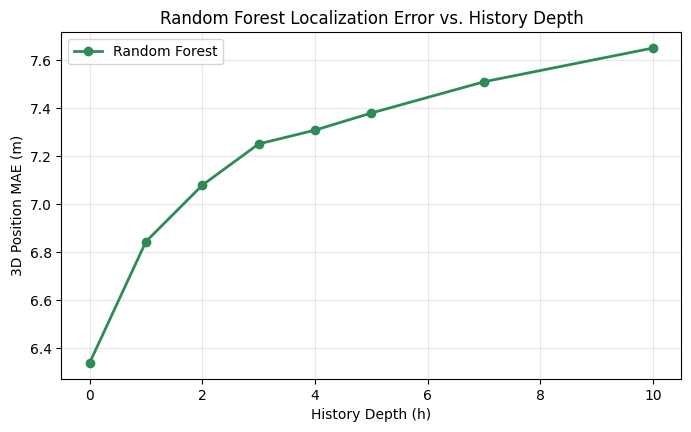

In [28]:
df_res = pd.DataFrame(results)
print('\nSweep Results Summary:')
print(df_res.to_string(index=False))

# Plot the curve
plt.figure(figsize=(8, 4.5))
plt.plot(df_res['H'], df_res['3D_MAE'], marker='o', lw=2, color='seagreen', label='Random Forest')
plt.xlabel('History Depth (h)')
plt.ylabel('3D Position MAE (m)')
plt.title('Random Forest Localization Error vs. History Depth')
plt.grid(alpha=0.3)
plt.legend()
plt.savefig(OUT_DIR / 'rf_history_sweep.png', dpi=150, bbox_inches='tight')
plt.show()

## Generate Report

In [29]:
import datetime
t_stamp = datetime.datetime.now().strftime('%Y-%m-%d_%H-%M-%S')
report_p = OUT_DIR / f'rf_sweep_report_{t_stamp}.md'

table_lines = [
    '| History Depth (h) | Feature Dim | 3D MAE (m) | X MAE (m) | Y MAE (m) | Z MAE (m) | Training Time (s) |',
    '| :---: | :---: | :---: | :---: | :---: | :---: | :---: |'
]
for r in results:
    table_lines.append(
        f"| {r['H']} | {r['FeatureDim']} | {r['3D_MAE']:.3f} | {r['X_MAE']:.3f} | {r['Y_MAE']:.3f} | {r['Z_MAE']:.3f} | {r['Time']:.1f} |"
    )
table_content = '\n'.join(table_lines)

report_content = f"""# Random Forest Localization History Sweep Report

* **Timestamp:** {datetime.datetime.now().strftime('%Y-%m-%d %H:%M:%S')}
* **Run ID:** `rf_sweep_report_{t_stamp}`

## 1. Configuration
* **Dataset:** 100% full dataset (subsampled to {SUBSAMPLE*100:.1f}% for training)
* **Feature Mode:** `{FEATURE_MODE}`
* **Model:** RandomForestRegressor(estimators={N_ESTIMATORS}, depth={MAX_DEPTH}, min_samples_leaf={MIN_SAMPLES_LEAF}, max_features={MAX_FEATURES})

## 2. Sweep Results Table

{{table_content}}

## 3. Analysis
This sweep traces how adding temporal sequence metrics impacts Random Forest regression. By stacking lag variables, we provide the decision nodes with multi-dimensional inputs that allow the forest to segment the physical space along trajectory vectors.
"""
report_content = report_content.replace('{table_content}', table_content)
report_p.write_text(report_content, encoding='utf-8')
print(f'Report saved to: {report_p}')

Report saved to: d:\gilad\projects\Academy\CSI-Location\results\notebook_experiments\random_forest\random_forest_sweep_2026-07-24_16-36-07\rf_sweep_report_2026-07-24_17-04-08.md
